**1**) Подготовка окружения (Colab)
1. Runtime - Change runtime type - T4 GPU

In [ ]:
#проверка подключения GPU
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-012d8cdc-6b3b-1c6f-4db2-1bcf05d5baad)


2. Установка зависимостей

In [ ]:
!pip -q install roboflow optuna==3.6.1 ultralytics opencv-python matplotlib
#проверка версии Ultralytics
!ultralytics version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 141.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.14


3. Импорт библиотек

In [ ]:
from google.colab import userdata
from roboflow import Roboflow
from pathlib import Path
from ultralytics import YOLO
import optuna
import gc
import yaml
import random
import matplotlib.pyplot as plt

**2**) Скачивание датасета с Roboflow

In [ ]:
api_key = userdata.get('ROBOFLOW_API_KEY')

if api_key:
  print('ROBOFLOW_API_KEY установлен:', bool(api_key))

ROBOFLOW_API_KEY установлен: True


In [ ]:
rf = Roboflow(api_key=api_key)
project = rf.workspace('shilpipyxeda').project('stars-and-constellation')
dataset = project.version(1).download('yolov11')
print('Dataset location:', dataset.location)

ds_path = Path(dataset.location)
data_yaml = ds_path / 'data.yaml'
#проверка data.yaml
print(data_yaml.read_text()[:1200])

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to stars-and-constellation-1 in yolov11:: 100%|██████████| 3512/3512 [00:01<00:00, 2317.50it/s]

Dataset location: /content/stars-and-constellation-1
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 16
names: ['aquila', 'bootes', 'canis_major', 'canis_minor', 'cassiopeia', 'cygnus', 'gemini', 'leo', 'lyra', 'moon', 'orion', 'pleiades', 'sagittarius', 'scorpius', 'taurus', 'ursa_major']

roboflow:
  workspace: shilpipyxeda
  project: stars-and-constellation
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/shilpipyxeda/stars-and-constellation/dataset/1


Проверка соответствия выборок датасета заявленным значениям

In [ ]:
def count_files(p: Path, exts):
    if not p.exists():
        return 0
    return sum(1 for f in p.rglob('*') if f.suffix.lower() in exts)

for s in ['train', 'valid', 'test']:
    n_img = count_files(ds_path / s / 'images', ('.jpg','.jpeg','.png','.bmp','.webp'))
    n_lbl = count_files(ds_path / s / 'labels', ('.txt',))
    print(f'{s:>5}: images={n_img}, labels={n_lbl}')


train: images=1225, labels=1225
valid: images=350, labels=350
 test: images=175, labels=175


**3**) Создание модели YOLO11m

In [ ]:
model = YOLO('yolo11m.pt')
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(256, eps=0.001, momentum=0.03, affine=True, track_

**4**) Baseline обучение с аугментациями

In [ ]:
results = model.train(
    data=str(data_yaml),
    epochs=15,
    imgsz=640,
    batch=16,
    patience=15,
    device=0,
    optimizer='AdamW',
    workers=2,
    project='runs_yolo11',
    name='stars_constellation_aug',
    seed=42,

    #Аугментации
    #Color jitter (аккуратно, т.к. изображения с мелкими деталями чувствительны к контрасту)
    hsv_h=0.015,              #изменение оттенка
    hsv_s=0.60,               #насыщенность
    hsv_v=0.40,               #яркость
    #Geometric
    degrees=5.0,              #поворот
    translate=0.05,           #сдвиг
    scale=0.30,               #масштаб
    shear=2.0,                #сдвиг/скос
    perspective=0.0005,       #перспективные искажения (очень мало)
    #Flips
    fliplr=0.5,               #горизонтальный флип
    #Mix-based (сильно влияет на детекцию; оставим умеренно)
    mosaic=0.6,               #мозаика
    mixup=0.1,                #mixup
)

results


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stars-and-constellation-1/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.6, multi_scale=0.0, name=stars_constellation_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7de9df79ec30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

**5**) Проверяем качество на valid

In [ ]:
best = YOLO(str('runs/detect/runs_yolo11/stars_constellation_aug/weights/best.pt'))
val_metrics = best.val(data=str(data_yaml), split='val', imgsz=640, device=0)
print(val_metrics)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,042,368 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 703.1±185.7 MB/s, size: 14.0 KB)
val: Scanning /content/stars-and-constellation-1/valid/labels.cache... 350 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 350/350 133.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.7it/s 12.6s
                   all        350       1360      0.847      0.891      0.895      0.468
                aquila         78         78      0.943          1      0.995      0.577
                bootes         77         77      0.994          1      0.995      0.578
           canis_major         68         68      0.901      0.912      0.954      0.473
           canis_minor         75         75      0.887      0.735      0.853      0.314
            cassiopeia    

Ключевые метрики

In [ ]:
metrics = best.val(data=str(data_yaml), split='val', imgsz=640, device=0)
print('\n=== Validation Metrics ===')
print('mAP50:', metrics.box.map50)
print('mAP50-95:', metrics.box.map)
print('Precision:', metrics.box.mp)
print('Recall:', metrics.box.mr)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 713.1±326.4 MB/s, size: 15.9 KB)
val: Scanning /content/stars-and-constellation-1/valid/labels.cache... 350 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 350/350 122.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.7it/s 13.2s
                   all        350       1360      0.847      0.891      0.895      0.468
                aquila         78         78      0.943          1      0.995      0.577
                bootes         77         77      0.994          1      0.995      0.578
           canis_major         68         68      0.901      0.912      0.954      0.473
           canis_minor         75         75      0.887      0.735      0.853      0.314
            cassiopeia        111        112       0.85      0.955      0.967      0.443
                cygnus

**6**) Подбор гиперпараметров (Optuna)

In [ ]:
N_TRIALS = 5
TRIAL_EPOCHS = 5
IMGSZ = 640
BATCH = 16
DEVICE = 0
HPO_ROOT = Path('runs_optuna_yolo11')
HPO_ROOT.mkdir(parents=True, exist_ok=True)

def objective(trial: optuna.Trial) -> float:

    lr0 = trial.suggest_float('lr0', 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 5e-3, log=True)
    warmup_epochs = trial.suggest_float('warmup_epochs', 0.0, 5.0)

    # аугментации
    hsv_h = trial.suggest_float('hsv_h', 0.0, 0.02)
    hsv_s = trial.suggest_float('hsv_s', 0.2, 0.8)
    hsv_v = trial.suggest_float('hsv_v', 0.2, 0.8)
    degrees = trial.suggest_float('degrees', 0.0, 10.0)
    translate = trial.suggest_float('translate', 0.0, 0.12)
    scale = trial.suggest_float('scale', 0.0, 0.5)
    shear = trial.suggest_float('shear', 0.0, 5.0)
    perspective = trial.suggest_float('perspective', 0.0, 0.001)
    fliplr = trial.suggest_float('fliplr', 0.0, 0.7)
    mosaic = trial.suggest_float('mosaic', 0.0, 0.9)
    mixup = trial.suggest_float('mixup', 0.0, 0.3)

    model = YOLO('yolo11m.pt')
    run_name = f'trial_{trial.number:03d}'

    model.train(
        data=str(data_yaml),
        epochs=TRIAL_EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        optimizer='AdamW',
        lr0=lr0,
        weight_decay=weight_decay,
        warmup_epochs=warmup_epochs,
        patience=0,  # в trial'ах early stopping лучше отключить для сравнимости
        project=str(HPO_ROOT),
        name=run_name,
        verbose=False,
        seed=42,

        hsv_h=hsv_h, hsv_s=hsv_s, hsv_v=hsv_v,
        degrees=degrees, translate=translate, scale=scale,
        shear=shear, perspective=perspective,
        fliplr=fliplr, flipud=0.0,
        mosaic=mosaic, mixup=mixup,
    )

    #val mAP50-95
    metrics = model.val(data=str(data_yaml), split='val', device=DEVICE, verbose=False)
    score = float(metrics.box.map)

    # лог в Optuna
    trial.set_user_attr('map50', float(metrics.box.map50))
    trial.set_user_attr('precision', float(metrics.box.mp))
    trial.set_user_attr('recall', float(metrics.box.mr))

    # чистим память
    del model
    gc.collect()

    return score




In [ ]:
study_name = 'yolo11_stars_constellation'

study = optuna.create_study(
    study_name=study_name,
    direction='maximize',
    load_if_exists=True,
)

study.optimize(objective, n_trials=N_TRIALS)


[I 2026-02-14 14:42:45,280] A new study created in memory with name: yolo11_stars_constellation


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stars-and-constellation-1/data.yaml, degrees=7.297884696416873, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.6715687318516965, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.011531296517449394, hsv_s=0.226679324320211, hsv_v=0.6307395104087887, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=3.3389442313489446e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.17329510319961547, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.7952831492875391, mult

[I 2026-02-14 14:48:25,153] Trial 0 finished with value: 0.382673568645293 and parameters: {'lr0': 3.3389442313489446e-05, 'weight_decay': 1.535698458801385e-06, 'warmup_epochs': 1.8435066159884372, 'hsv_h': 0.011531296517449394, 'hsv_s': 0.226679324320211, 'hsv_v': 0.6307395104087887, 'degrees': 7.297884696416873, 'translate': 0.10262180245386586, 'scale': 0.35237765501118123, 'shear': 1.299238478889977, 'perspective': 0.00022766932156004983, 'fliplr': 0.6715687318516965, 'mosaic': 0.7952831492875391, 'mixup': 0.17329510319961547}. Best is trial 0 with value: 0.382673568645293.


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stars-and-constellation-1/data.yaml, degrees=2.873708346798325, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.01872150745763146, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.019970515320773156, hsv_s=0.25637963388096463, hsv_v=0.570507255553892, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=9.087513515251446e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.08058255269457516, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.00761898969455026, mu

[I 2026-02-14 14:54:14,034] Trial 1 finished with value: 0.5106640078787876 and parameters: {'lr0': 9.087513515251446e-05, 'weight_decay': 2.3976932357004226e-06, 'warmup_epochs': 3.0413303159033767, 'hsv_h': 0.019970515320773156, 'hsv_s': 0.25637963388096463, 'hsv_v': 0.570507255553892, 'degrees': 2.873708346798325, 'translate': 0.08703186309567616, 'scale': 0.092817152574386, 'shear': 4.415492363416592, 'perspective': 6.36119505256153e-05, 'fliplr': 0.01872150745763146, 'mosaic': 0.00761898969455026, 'mixup': 0.08058255269457516}. Best is trial 1 with value: 0.5106640078787876.


...

[I 2026-02-14 14:59:54,850] Trial 2 finished with value: 0.4374641277630711 and parameters: {'lr0': 0.0009814446639463885, 'weight_decay': 0.0005896757299316034, 'warmup_epochs': 3.269494060161255, 'hsv_h': 0.007401641372149768, 'hsv_s': 0.3549981391994491, 'hsv_v': 0.744783345599745, 'degrees': 2.1661800147755326, 'translate': 0.07295297596944104, 'scale': 0.20283225265716975, 'shear': 2.121719637007338, 'perspective': 0.00044494261580324003, 'fliplr': 0.2212717828026348, 'mosaic': 0.6307848034809879, 'mixup': 0.19811138457313074}. Best is trial 1 with value: 0.5106640078787876.


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stars-and-constellation-1/data.yaml, degrees=8.52685590967887, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.3839501651988384, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.011640248464123546, hsv_s=0.41731905589367385, hsv_v=0.7288229533692459, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00020656656437731443, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.01135231112240227, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.638119287445148, mult

[I 2026-02-14 15:05:44,309] Trial 3 finished with value: 0.44202693679770755 and parameters: {'lr0': 0.00020656656437731443, 'weight_decay': 2.7402185340437692e-05, 'warmup_epochs': 4.077762837216141, 'hsv_h': 0.011640248464123546, 'hsv_s': 0.41731905589367385, 'hsv_v': 0.7288229533692459, 'degrees': 8.52685590967887, 'translate': 0.06834188673165605, 'scale': 0.44110779109544745, 'shear': 1.668102806766802, 'perspective': 0.00041049343226595936, 'fliplr': 0.3839501651988384, 'mosaic': 0.638119287445148, 'mixup': 0.01135231112240227}. Best is trial 1 with value: 0.5106640078787876.


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stars-and-constellation-1/data.yaml, degrees=6.815706873597839, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.29380472480841224, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.008687226598408407, hsv_s=0.7760372175416832, hsv_v=0.564023039682872, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00023594896134929177, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.29387245985175114, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.4732899331135061, mul

[I 2026-02-14 15:11:26,614] Trial 4 finished with value: 0.4542712734661577 and parameters: {'lr0': 0.00023594896134929177, 'weight_decay': 7.748419608540039e-05, 'warmup_epochs': 4.044399976278297, 'hsv_h': 0.008687226598408407, 'hsv_s': 0.7760372175416832, 'hsv_v': 0.564023039682872, 'degrees': 6.815706873597839, 'translate': 0.10569887847219075, 'scale': 0.10758750712684279, 'shear': 1.955642297700892, 'perspective': 0.0002979827608362755, 'fliplr': 0.29380472480841224, 'mosaic': 0.4732899331135061, 'mixup': 0.29387245985175114}. Best is trial 1 with value: 0.5106640078787876.


Лучшие подобранные гиперпараметры

In [ ]:
print('Best trial:', study.best_trial.number)
print('Best mAP50-95:', study.best_value)
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Best trial: 1
Best mAP50-95: 0.5106640078787876
Best params:
  lr0: 9.087513515251446e-05
  weight_decay: 2.3976932357004226e-06
  warmup_epochs: 3.0413303159033767
  hsv_h: 0.019970515320773156
  hsv_s: 0.25637963388096463
  hsv_v: 0.570507255553892
  degrees: 2.873708346798325
  translate: 0.08703186309567616
  scale: 0.092817152574386
  shear: 4.415492363416592
  perspective: 6.36119505256153e-05
  fliplr: 0.01872150745763146
  mosaic: 0.00761898969455026
  mixup: 0.08058255269457516


**7**) Финальное обучение. Применяем лучшие подобранные гиперпараметры

In [ ]:
best_params = study.best_params

final_model = YOLO('yolo11m.pt')

final_results = final_model.train(
    data=str(data_yaml),
    epochs=15,
    imgsz=640,
    batch=16,
    device=0,
    optimizer='AdamW',
    workers=2,
    seed=42,
    lr0=best_params['lr0'],
    weight_decay=best_params['weight_decay'],
    warmup_epochs=best_params['warmup_epochs'],
    patience=15,
    project='runs_yolo11',
    name='stars_constellation_optuna_best',

    hsv_h=best_params['hsv_h'],
    hsv_s=best_params['hsv_s'],
    hsv_v=best_params['hsv_v'],
    degrees=best_params['degrees'],
    translate=best_params['translate'],
    scale=best_params['scale'],
    shear=best_params['shear'],
    perspective=best_params['perspective'],
    fliplr=best_params['fliplr'],
    mosaic=best_params['mosaic'],
    mixup=best_params['mixup'],
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stars-and-constellation-1/data.yaml, degrees=2.873708346798325, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.01872150745763146, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.019970515320773156, hsv_s=0.25637963388096463, hsv_v=0.570507255553892, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=9.087513515251446e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.08058255269457516, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=0.00761898969455026, m

Оценка финального обучения по valid (для сравнения)

In [ ]:
# Ищем самый свежий best.pt (финальный run обычно самый новый)
candidates = list(Path('runs').rglob('stars_constellation_optuna_best/weights/best.pt'))

assert candidates, 'Финальные веса не найдены. Проверь имя run.'

best_path = sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]
print('Using best weights:', best_path)

model = YOLO(str(best_path))
m_val = model.val(data=str(data_yaml), split='val', device=0)

print('\n=== FINAL VALID (для сравнения) ===')
print('FINAL VALID mAP50-95:', float(m_val.box.map))
print('FINAL VALID mAP50:', float(m_val.box.map50))
print('FINAL VALID P:', float(m_val.box.mp))
print('FINAL VALID R:', float(m_val.box.mr))

Using best weights: runs/detect/runs_yolo11/stars_constellation_optuna_best/weights/best.pt
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,042,368 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 764.1±272.1 MB/s, size: 14.8 KB)
val: Scanning /content/stars-and-constellation-1/valid/labels.cache... 350 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 350/350 122.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.8it/s 12.0s
                   all        350       1360      0.936      0.952      0.959      0.585
                aquila         78         78      0.987      0.995      0.995       0.72
                bootes         77         77      0.989          1      0.995      0.686
           canis_major         68         68      0.933      0.971      0.991      0.607
           canis_minor 

Оценка на test

In [ ]:
best_weights = Path('runs/detect/runs_yolo11/stars_constellation_aug/weights/best.pt')
assert best_weights.exists(), f'best.pt не найден: {best_weights}'

data_yaml_path = Path(data_yaml)
assert data_yaml_path.exists(), f'data.yaml не найден: {data_yaml_path}'

print(data_yaml)

# 2) Проверяем наличие test в yaml и что папка существует
cfg = yaml.safe_load(data_yaml_path.read_text())
test_path = str(ds_path / 'test' / 'images')

def resolve_path(p):
    if p is None:
        return None
    if isinstance(p, (list, tuple)):
        p = p[0] if p else None
    if p is None:
        return None
    p = Path(p)
    return p if p.is_absolute() else (data_yaml_path.parent / p)

test_images_dir = resolve_path(test_path)

# Roboflow иногда указывает на split root, а не на images
if test_images_dir and test_images_dir.name != 'images':
    cand = test_images_dir / 'images'
    if cand.exists():
        test_images_dir = cand

if not test_images_dir or not test_images_dir.exists():
    raise RuntimeError(
        'Test split не найден или путь некорректный.\n'
        'Проверь, что в data.yaml есть ключ test и папка существует.'
    )

print('Using weights:', best_weights)
print('Test images dir:', test_images_dir)

# 3) Запускаем оценку на test (один прогон)
model = YOLO(str(best_weights))
metrics = model.val(data=str(data_yaml_path), split='test', device=0)

print('\n=== TEST GENERALIZATION ===')
print('mAP50-95:', float(metrics.box.map))
print('mAP50   :', float(metrics.box.map50))
print('Precision:', float(metrics.box.mp))
print('Recall   :', float(metrics.box.mr))

/content/stars-and-constellation-1/data.yaml
Using weights: runs/detect/runs_yolo11/stars_constellation_aug/weights/best.pt
Test images dir: /content/stars-and-constellation-1/test/images
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,042,368 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6.8±5.7 MB/s, size: 13.2 KB)
val: Scanning /content/stars-and-constellation-1/test/labels... 175 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 175/175 1.6Kit/s 0.1s
val: New cache created: /content/stars-and-constellation-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.7it/s 6.5s
                   all        175        666      0.856      0.905      0.905      0.463
                aquila         35         35      0.929          1      0.982        0.5
                bootes         36         

**8**) Визуализация предсказаний на тестовой выборке

Test images found: 175

0: 640x640 1 cassiopeia, 1 ursa_major, 32.1ms
1: 640x640 1 cassiopeia, 1 ursa_major, 32.1ms
2: 640x640 1 aquila, 1 bootes, 1 leo, 1 lyra, 1 sagittarius, 1 scorpius, 32.1ms
3: 640x640 1 aquila, 1 bootes, 1 cygnus, 1 lyra, 1 sagittarius, 1 scorpius, 32.1ms
4: 640x640 1 cygnus, 2 moons, 2 pleiadess, 1 taurus, 32.1ms
5: 640x640 1 cassiopeia, 1 cygnus, 1 ursa_major, 32.1ms
Speed: 2.2ms preprocess, 32.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


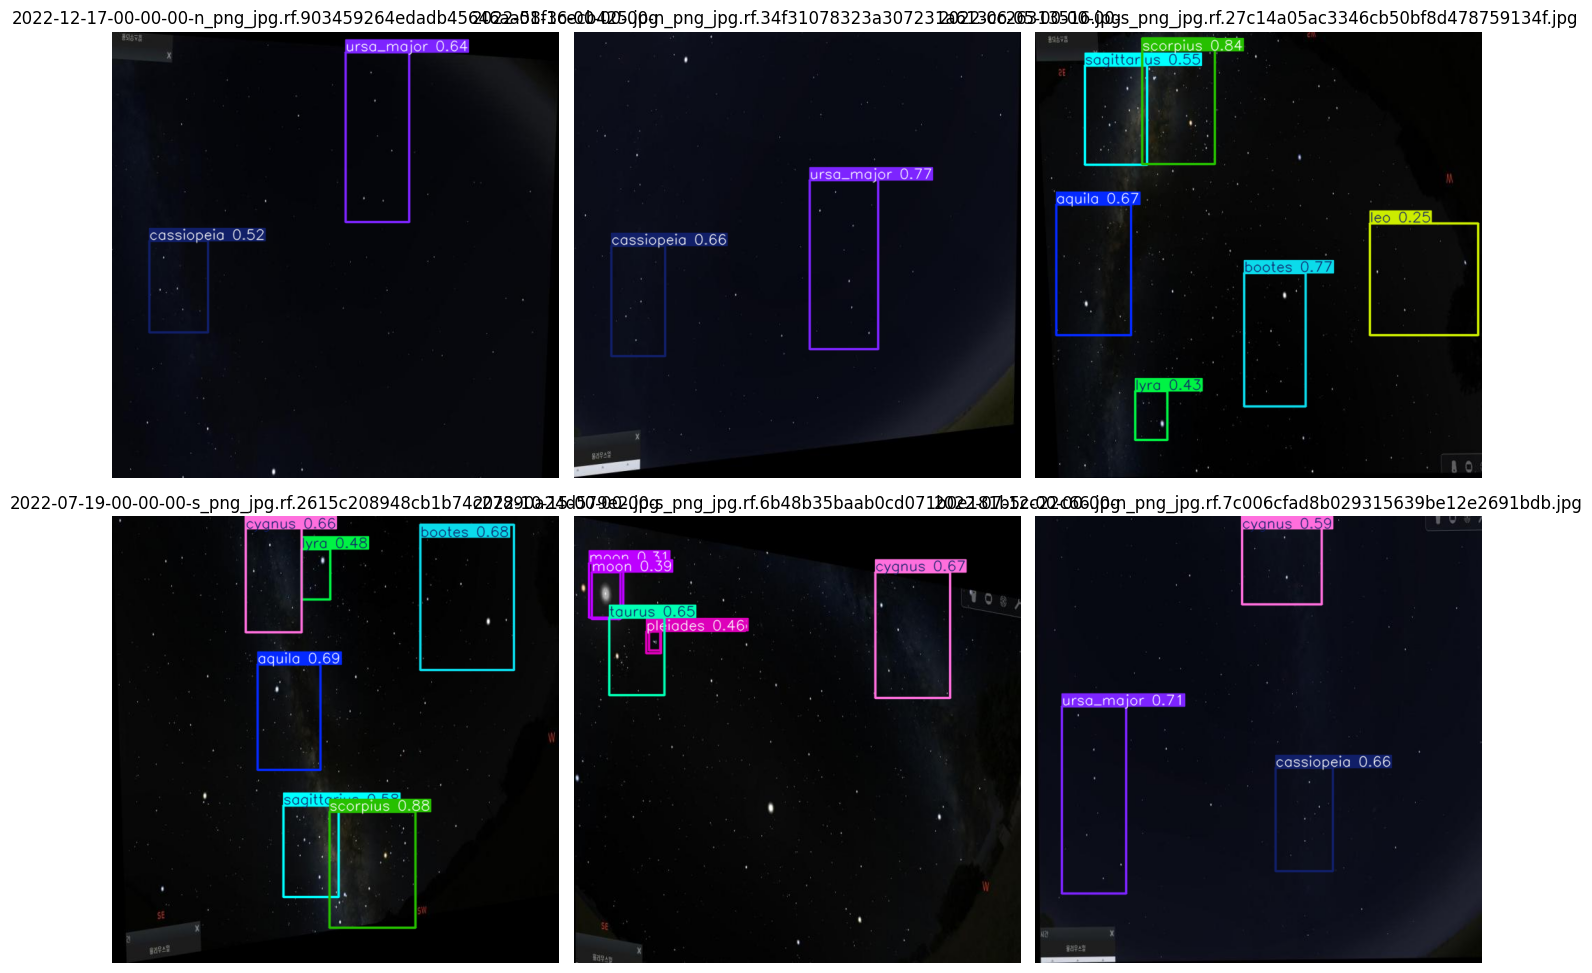

In [ ]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
test_imgs = []
for ext in IMG_EXTS:
    test_imgs += list(test_images_dir.rglob(f'*{ext}'))

print('Test images found:', len(test_imgs))
sample = random.sample(test_imgs, k=min(6, len(test_imgs)))

preds = model.predict(
    source=[str(p) for p in sample],
    imgsz=640,
    conf=0.25,
    iou=0.7,
    device=0
)

plt.figure(figsize=(14, 10))
for i, r in enumerate(preds):
    img = r.plot()[..., ::-1]  # BGR->RGB
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(Path(r.path).name)
    plt.axis('off')
plt.tight_layout()
plt.show()


Вывод параметров для отчёта

In [ ]:
fixed_hparams = {
    'dataset': 'Stars and Constellation (Roboflow Universe)',
    'task': 'Object Detection',
    'model': 'yolo11m.pt (pretrained, COCO)',
    'imgsz': 640,
    'batch': 16,
    'optimizer': 'AdamW',
    'epochs baseline': 15,
    'epochs per Optuna trial': 5,
    'n_trials (Optuna)': 5,
    'epochs final': 15,
    'patience': '0 (Optuna), 15 (final)',
    'device': 'GPU (Colab)',
    'leakage control': 'test используется только в конце (только финальная оценка)',
}

search_space = {
    'lr0': '[1e-5, 5e-3] log-uniform',
    'weight_decay': '[1e-6, 5e-3] log-uniform',
    'warmup_epochs': '[0.0, 5.0] uniform',
    'mosaic': '[0.0, 0.9] uniform',
    'mixup': '[0.0, 0.3] uniform',
    'hsv_h': '[0.0, 0.02] uniform',
    'hsv_s': '[0.2, 0.8] uniform',
    'hsv_v': '[0.2, 0.8] uniform',
    'degrees': '[0.0, 10.0] uniform',
    'translate': '[0.0, 0.12] uniform',
    'scale': '[0.0, 0.5] uniform',
    'shear': '[0.0, 5.0] uniform',
    'perspective': '[0.0, 0.001] uniform',
    'fliplr': '[0.0, 0.7] uniform',
}

print('=== Фиксированные гиперпараметры ===')
for k, v in fixed_hparams.items():
    print(f'- {k}: {v}')

print('\n=== Пространство подбираемых гиперпараметров ===')
for k, v in search_space.items():
    print(f'- {k}: {v}')

print('\n=== Способ подбора гиперпараметров ===')
print('- Optuna (TPE): короткие прогоны на train, оценка mAP50-95 на valid')
print('- Test split не используется на этапах tuning/final selection (только финальная оценка)')

print('\n=== Лучшие найденные гиперпараметры ===')
if 'study' in globals() and getattr(study, 'best_params', None):
    print(study.best_params)
else:
    print('study.best_params недоступен (Optuna не запускался в этой сессии).')


=== Фиксированные гиперпараметры ===
- dataset: Stars and Constellation (Roboflow Universe)
- task: Object Detection
- model: yolo11m.pt (pretrained, COCO)
- imgsz: 640
- batch: 16
- optimizer: AdamW
- epochs baseline: 15
- epochs per Optuna trial: 5
- n_trials (Optuna): 5
- epochs final: 15
- patience: 0 (Optuna), 15 (final)
- device: GPU (Colab)
- leakage control: test используется только в конце (только финальная оценка)

=== Пространство подбираемых гиперпараметров ===
- lr0: [1e-5, 5e-3] log-uniform
- weight_decay: [1e-6, 5e-3] log-uniform
- warmup_epochs: [0.0, 5.0] uniform
- mosaic: [0.0, 0.9] uniform
- mixup: [0.0, 0.3] uniform
- hsv_h: [0.0, 0.02] uniform
- hsv_s: [0.2, 0.8] uniform
- hsv_v: [0.2, 0.8] uniform
- degrees: [0.0, 10.0] uniform
- translate: [0.0, 0.12] uniform
- scale: [0.0, 0.5] uniform
- shear: [0.0, 5.0] uniform
- perspective: [0.0, 0.001] uniform
- fliplr: [0.0, 0.7] uniform

=== Способ подбора гиперпараметров ===
- Optuna (TPE): короткие прогоны на train, оце